In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [2]:
df = pd.read_csv("/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (920, 16)
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4          

In [13]:
# -----------------------------
# 3. Data Cleaning (Corrected)
# -----------------------------

# Convert target column to binary
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object','bool']).columns

# Fill numeric columns with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode (most frequent value)
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())


Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Missing Values After Cleaning:
 id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


/tmp/ipykernel_55/381075834.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_55/381075834.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [15]:
# Convert categorical variables to numeric using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

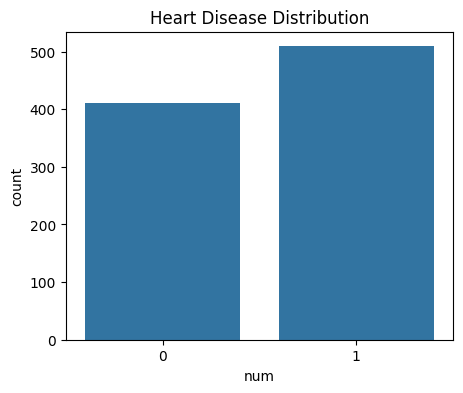

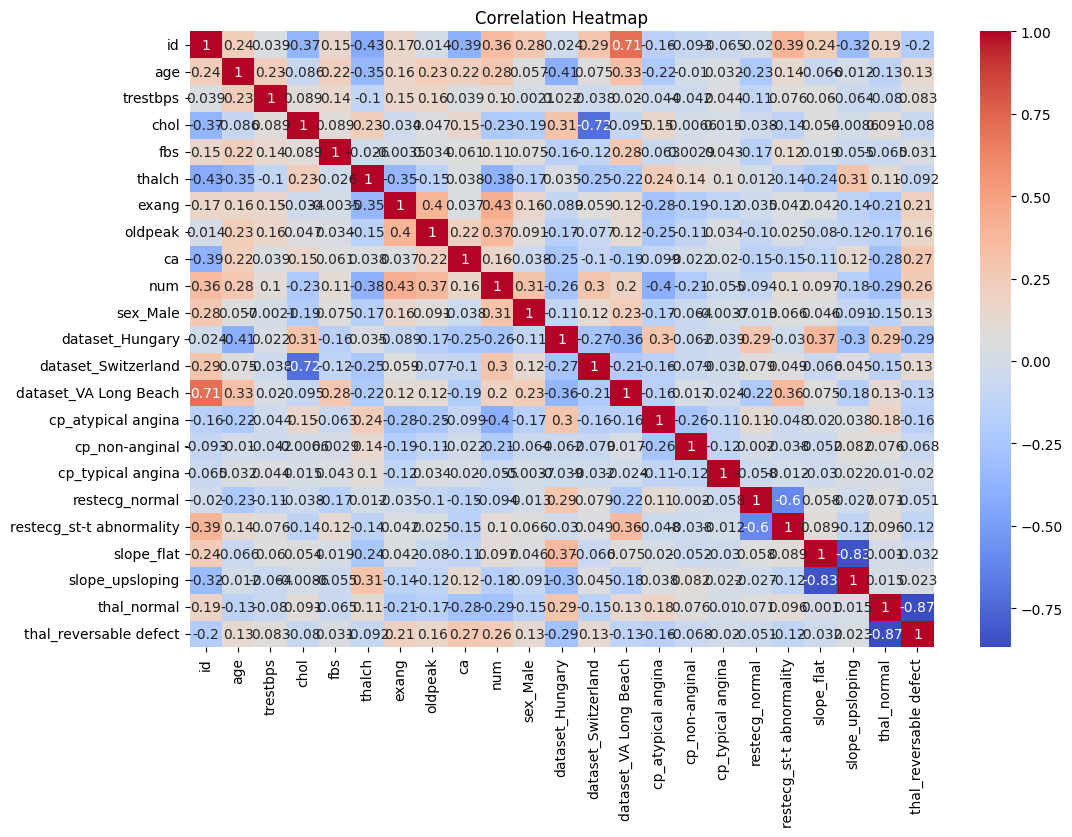

In [16]:

# -----------------------------
# 4. Exploratory Data Analysis
# -----------------------------

# Target Distribution
plt.figure(figsize=(5,4))
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [18]:

# -----------------------------
# 5. Prepare Data
# -----------------------------
X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:


# -----------------------------
# 6. Train Logistic Regression Model
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)


Accuracy: 0.842391304347826


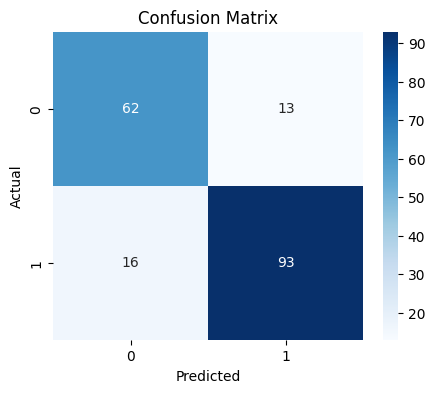

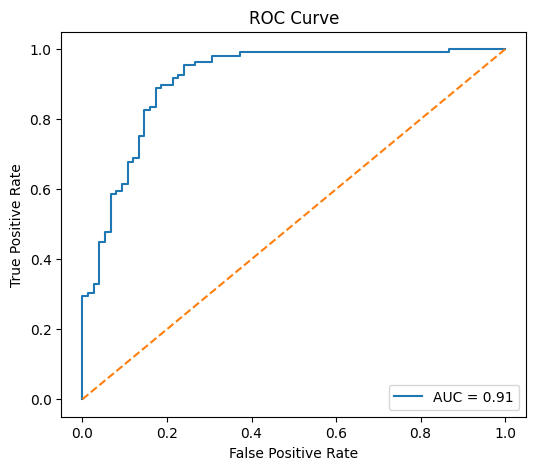

ROC-AUC Score: 0.9110703363914373


In [22]:

# 7. Model Evaluation
# -----------------------------

# Accuracy
accuracy = accuracy_score(y_test, preds)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
probs = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = "+str(round(auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc)

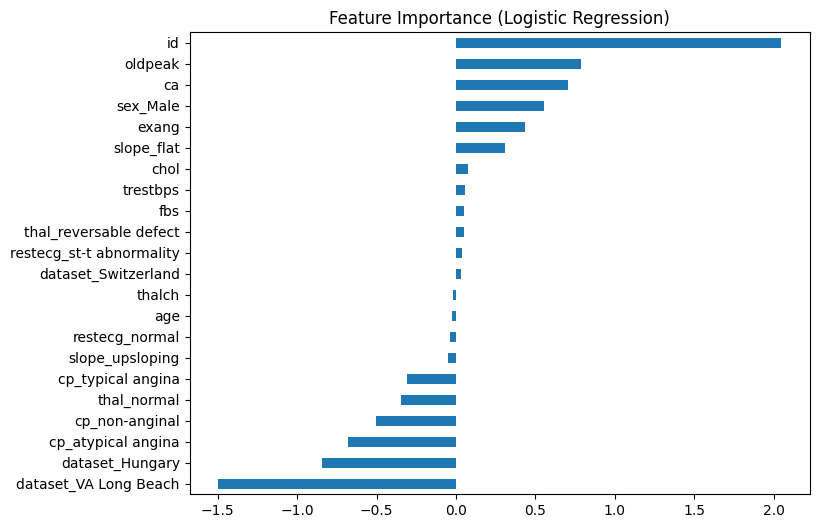


Top Important Features:

id                          2.049706
oldpeak                     0.790358
ca                          0.708337
sex_Male                    0.551956
exang                       0.436367
slope_flat                  0.307068
chol                        0.073674
trestbps                    0.057786
fbs                         0.051075
thal_reversable defect      0.049706
restecg_st-t abnormality    0.039582
dataset_Switzerland         0.032962
thalch                     -0.016794
age                        -0.025760
restecg_normal             -0.035369
slope_upsloping            -0.053161
cp_typical angina          -0.309982
thal_normal                -0.344945
cp_non-anginal             -0.506288
cp_atypical angina         -0.682150
dataset_Hungary            -0.843693
dataset_VA Long Beach      -1.500138
dtype: float64


In [23]:


# -----------------------------
# 8. Feature Importance
# -----------------------------
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title("Feature Importance (Logistic Regression)")
plt.show()

print("\nTop Important Features:\n")
print(importance.sort_values(ascending=False))